In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [4]:
df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')
print("Dataset loaded!")
print("Shape:", df.shape)

Dataset loaded!
Shape: (2640, 12)


In [5]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [6]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


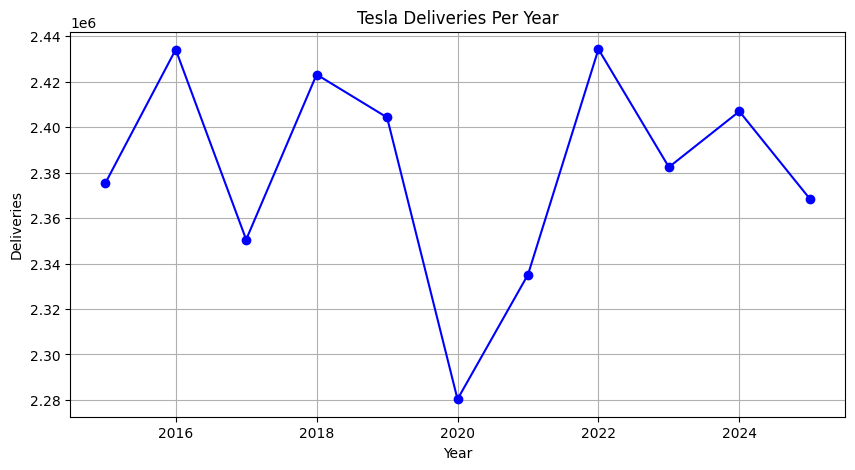

In [7]:
yearly = df.groupby('Year')['Estimated_Deliveries'].sum()
plt.figure(figsize=(10,5))
plt.plot(yearly.index, yearly.values, marker='o', color='blue')
plt.title('Tesla Deliveries Per Year')
plt.xlabel('Year')
plt.ylabel('Deliveries')
plt.grid(True)
plt.show()

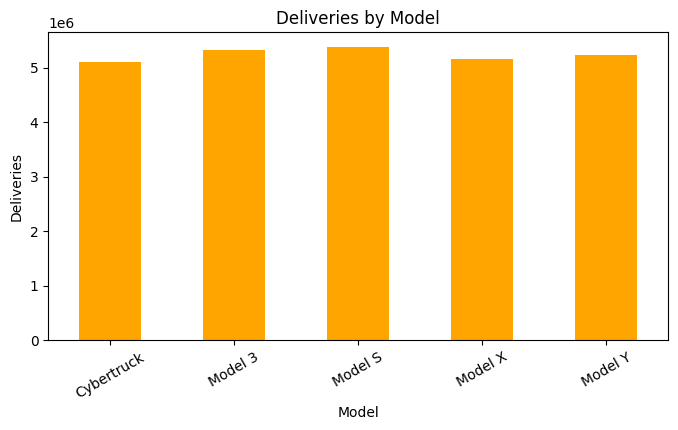

In [8]:
model_del = df.groupby('Model')['Estimated_Deliveries'].sum()
plt.figure(figsize=(8,4))
model_del.plot(kind='bar', color='orange')
plt.title('Deliveries by Model')
plt.xlabel('Model')
plt.ylabel('Deliveries')
plt.xticks(rotation=30)
plt.show()

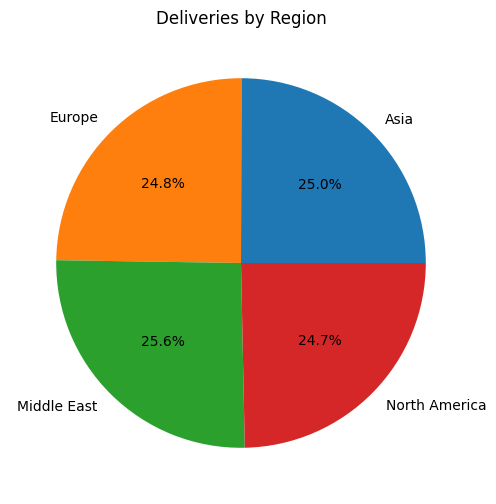

In [9]:
region_del = df.groupby('Region')['Estimated_Deliveries'].sum()
plt.figure(figsize=(6,6))
plt.pie(region_del, labels=region_del.index, autopct='%1.1f%%')
plt.title('Deliveries by Region')
plt.show()

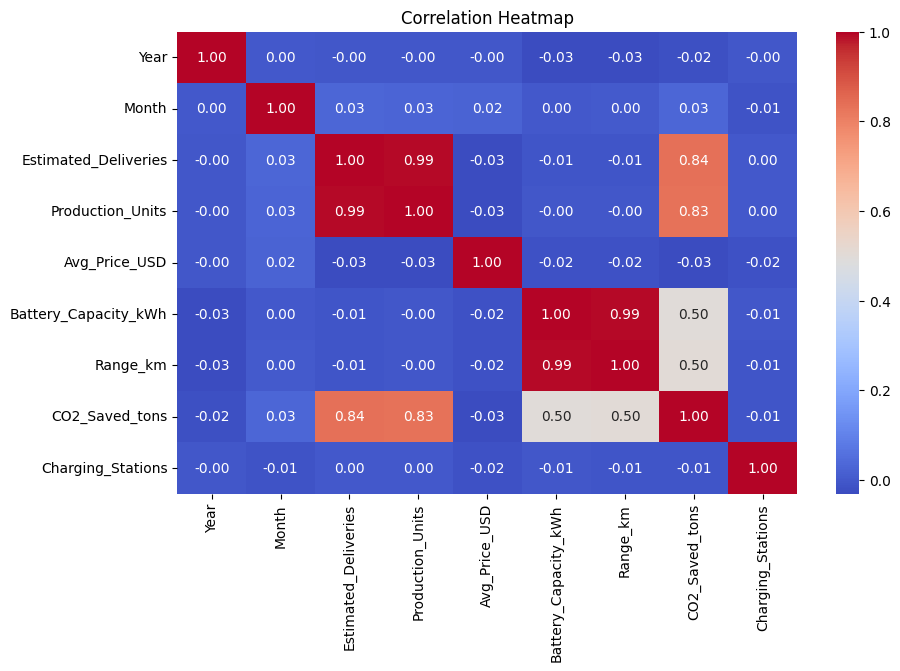

In [10]:
plt.figure(figsize=(10,6))
num_df = df.select_dtypes(include='number')
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [11]:
before = len(df)
df = df.drop_duplicates()
print("Rows before:", before)
print("Rows after:", len(df))

Rows before: 2640
Rows after: 2640


In [12]:
le_region = LabelEncoder()
le_model = LabelEncoder()

df['Region_enc'] = le_region.fit_transform(df['Region'])
df['Model_enc'] = le_model.fit_transform(df['Model'])

print("Encoding done!")
print(df[['Region', 'Region_enc', 'Model', 'Model_enc']].head())

Encoding done!
          Region  Region_enc    Model  Model_enc
0         Europe           1  Model S          2
1           Asia           0  Model X          3
2  North America           3  Model X          3
3  North America           3  Model 3          1
4    Middle East           2  Model Y          4


In [13]:
scaler = StandardScaler()

cols_to_scale = ['Estimated_Deliveries', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print("Scaling done!")
df[cols_to_scale].head()

Scaling done!


,Estimated_Deliveries,Avg_Price_USD,Battery_Capacity_kWh,Range_km,Charging_Stations
0,1.962744,0.395982,1.581223,1.685972,0.944062
1,-1.556514,-1.128346,-0.578883,-0.515183,-0.372490
2,-0.384021,1.639209,-0.242866,-0.167632,1.481407
3,-0.855661,0.218076,1.581223,1.752172,0.115560
4,0.623043,1.488085,1.581223,1.330146,-0.060576


In [14]:
df['Year_Month'] = df['Year'] * 12 + df['Month']


df['CO2_per_Delivery'] = df['CO2_Saved_tons'] / (df['Estimated_Deliveries'] + 1)

print("New features added!")
print(df[['Year_Month', 'CO2_per_Delivery']].head())

New features added!
   Year_Month  CO2_per_Delivery
0       24281        628.950664
1       24182       -448.254957
2       24229        983.133526
3       24254       4850.166605
4       24204        755.913582


In [15]:
features = ['Year', 'Month', 'Year_Month', 'Region_enc', 'Model_enc',
            'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations',
            'Avg_Price_USD', 'Estimated_Deliveries']

target = 'Production_Units'

X = df[features]
y = df[target]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (2112, 10)
Test size: (528, 10)


In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression Results:")
print("R2 Score:", round(r2_score(y_test, y_pred_lr), 4))
print("MAE     :", round(mean_absolute_error(y_test, y_pred_lr), 2))

Linear Regression Results:
R2 Score: 0.9883
MAE     : 364.0


In [17]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print("R2 Score:", round(r2_score(y_test, y_pred_rf), 4))
print("MAE     :", round(mean_absolute_error(y_test, y_pred_rf), 2))

Random Forest Results:
R2 Score: 0.986
MAE     : 394.65


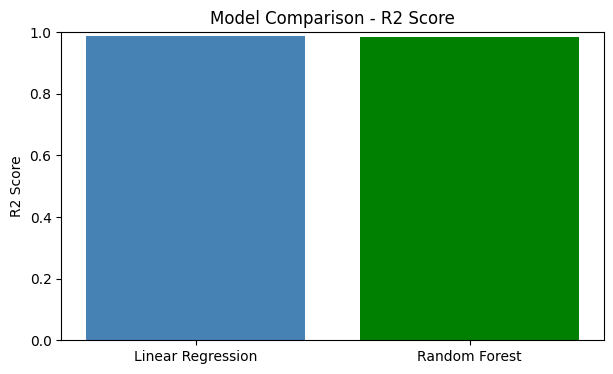

In [18]:
models = ['Linear Regression', 'Random Forest']
scores = [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_rf)]

plt.figure(figsize=(7,4))
plt.bar(models, scores, color=['steelblue', 'green'])
plt.title('Model Comparison - R2 Score')
plt.ylabel('R2 Score')
plt.ylim(0, 1)
plt.show()

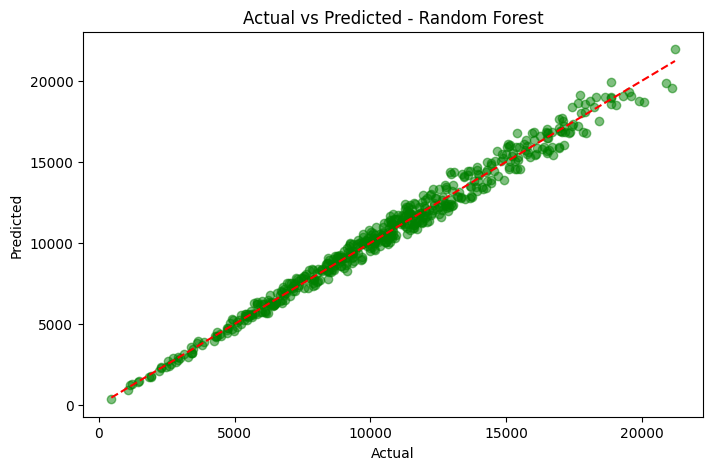

In [19]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Actual vs Predicted - Random Forest')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [20]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best R2 Score  :", round(grid.best_score_, 4))

Best Parameters: {'max_depth': 5, 'n_estimators': 100}
Best R2 Score  : 0.987


In [21]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("After Tuning:")
print("R2 Score:", round(r2_score(y_test, y_pred_best), 4))
print("MAE     :", round(mean_absolute_error(y_test, y_pred_best), 2))


After Tuning:
R2 Score: 0.987
MAE     : 381.82


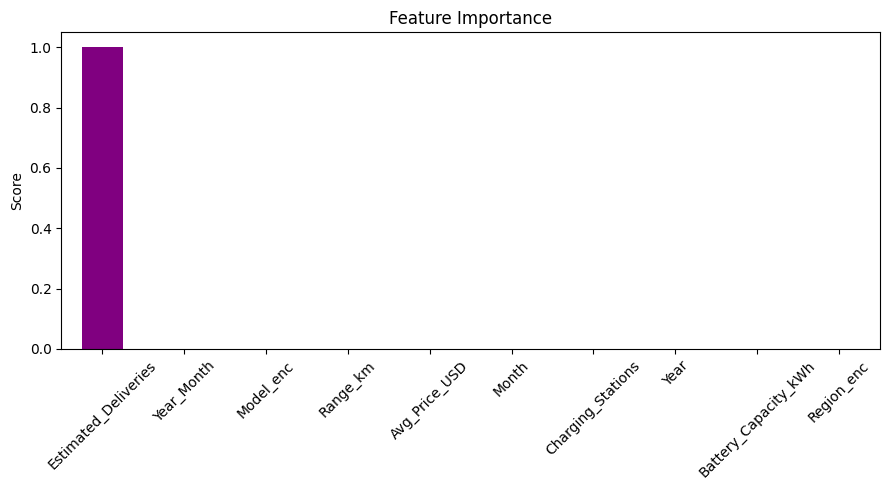

In [22]:
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(9,5))
feat_imp.plot(kind='bar', color='purple')
plt.title('Feature Importance')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
ts = df.groupby(['Year', 'Month'])['Estimated_Deliveries'].sum().reset_index()
ts = ts.sort_values(['Year', 'Month']).reset_index(drop=True)
ts['Time_Index'] = range(len(ts))

print(ts.shape)
ts.head()

(132, 4)


,Year,Month,Estimated_Deliveries,Time_Index
0,2015,1,-3.878831,0
1,2015,2,-8.485199,1
2,2015,3,-3.526371,2
3,2015,4,6.906631,3
4,2015,5,-3.603369,4


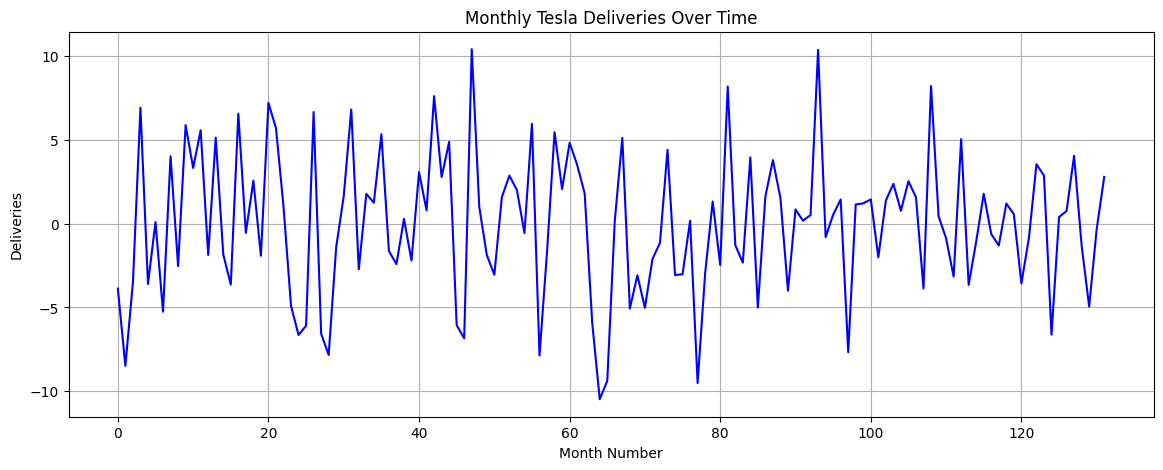

In [24]:
plt.figure(figsize=(14,5))
plt.plot(ts['Time_Index'], ts['Estimated_Deliveries'], color='blue')
plt.title('Monthly Tesla Deliveries Over Time')
plt.xlabel('Month Number')
plt.ylabel('Deliveries')
plt.grid(True)
plt.show()

In [25]:
split = int(len(ts) * 0.8)

X_ts = ts[['Time_Index']]
y_ts = ts['Estimated_Deliveries']

X_train_ts = X_ts[:split]
X_test_ts  = X_ts[split:]
y_train_ts = y_ts[:split]
y_test_ts  = y_ts[split:]


ts_model = LinearRegression()
ts_model.fit(X_train_ts, y_train_ts)
y_pred_ts = ts_model.predict(X_test_ts)

print("Time Series R2 Score:", round(r2_score(y_test_ts, y_pred_ts), 4))
print("Time Series MAE     :", round(mean_absolute_error(y_test_ts, y_pred_ts), 2))

Time Series R2 Score: -0.0057
Time Series MAE     : 2.52


In [26]:
last = ts['Time_Index'].max()
future = np.array(range(last+1, last+13)).reshape(-1, 1)
future_preds = ts_model.predict(future)

print("Forecast for next 12 months:")
for i, val in enumerate(future_preds, 1):
    print(f"  Month +{i}: {int(val):,}")

Forecast for next 12 months:
  Month +1: 0
  Month +2: 0
  Month +3: 0
  Month +4: 0
  Month +5: 0
  Month +6: 0
  Month +7: 0
  Month +8: 0
  Month +9: 0
  Month +10: 0
  Month +11: 0
  Month +12: 0


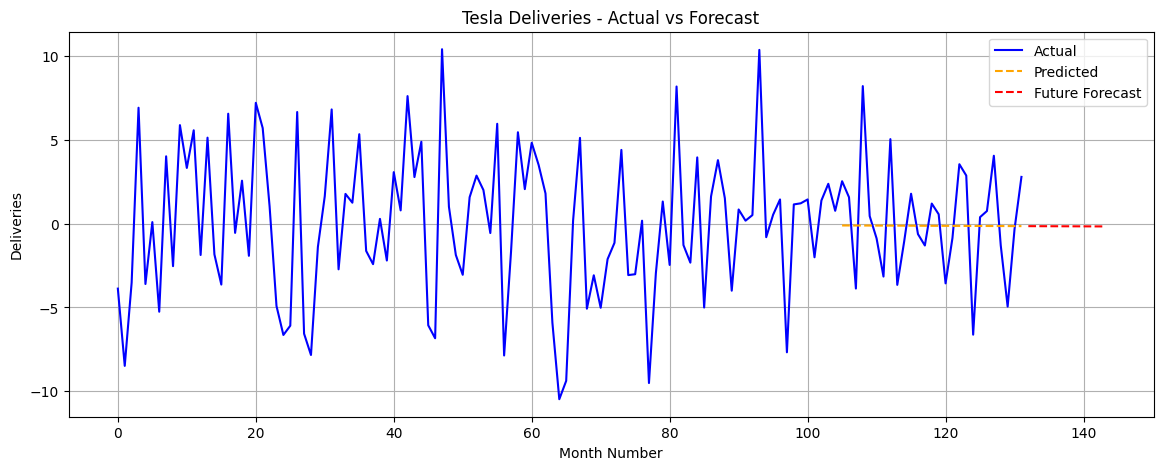

In [27]:
plt.figure(figsize=(14,5))
plt.plot(ts['Time_Index'], ts['Estimated_Deliveries'], label='Actual', color='blue')
plt.plot(X_test_ts, y_pred_ts, label='Predicted', color='orange', linestyle='--')
plt.plot(future, future_preds, label='Future Forecast', color='red', linestyle='--')
plt.title('Tesla Deliveries - Actual vs Forecast')
plt.xlabel('Month Number')
plt.ylabel('Deliveries')
plt.legend()
plt.grid(True)
plt.show()